Reinforcement learning from human feedback (RLHF) is a fine-tuning mechanism which uses human annotation- (aka human feedback) - to help model adapt human values and preferences.<br>
RLHF is most commonly applied after other fine tunning, including instruction fine-tuning.<br>
We can also use RLHF to fine-tune for personlised model.

## Human Alignment: Helpful, Honest & Harmless

### Helpful

your model may not generate a helpful completion for your prompt, Consider asking your model, "Which cities in the united states are the most popular for summer vacation?" The model responds with "Most Major cities in the United states are popular for summer vacation." This is clearly not a helpful response and could use some improvement.

### Honest

Your model might also generate misleading or incorrect responses. Let's say you ask model if shaking your head can improve your hearing and the model sometimes generate a confident, yet totally incorrect, response such as ,"yes! shaking your head can improve your hearing". WHich is not scientifically proven to be true.

### Harmless

We don't want model to generate harmful, offensive or criminal responses. Instead of responding as such, you can fine-tune your model to either ignore the question or respond with a less toxic response that does not propogate offensiveness or encourage criminal behavior. For eg, if you ask your model how to hack into a computer system, your model can respond with "I am unable to answer this question because i do not encourage criminal behavior."

## Reinforcement learning

Lets understand reinforcement learning from an example of AWS DeepRacer, where a player trains a small driverless car to autonomously drive on a racetrack and avoid crashing. Objective is to complete the track in the shortest amount of time.<br>

The agent is the car that is learning policy or model based on rewards given to the car for staying on the track and choosing the proper actions.<br>
The environment is the racetrack, car's current position and speed on the track is state and action is all the possible actions a car can choose based on the current state, including steering left/right, braking and accelerating. Agent (car) makes decision by following a RL policy. So agent has to choose the righ action for given state which would result in covering racetrack in shortest time and indirectly will get maximum reward.<br>

After each iteration, agent collects overall rewards that affects agents actions in the next iteration. This learning process is iterative and involves trial and error. Sequence of the states and action that lead to a reward are often called a playout. As Agent gathers more experience through additional playouts, it will learn to follow actions that produce a high reward.<br>

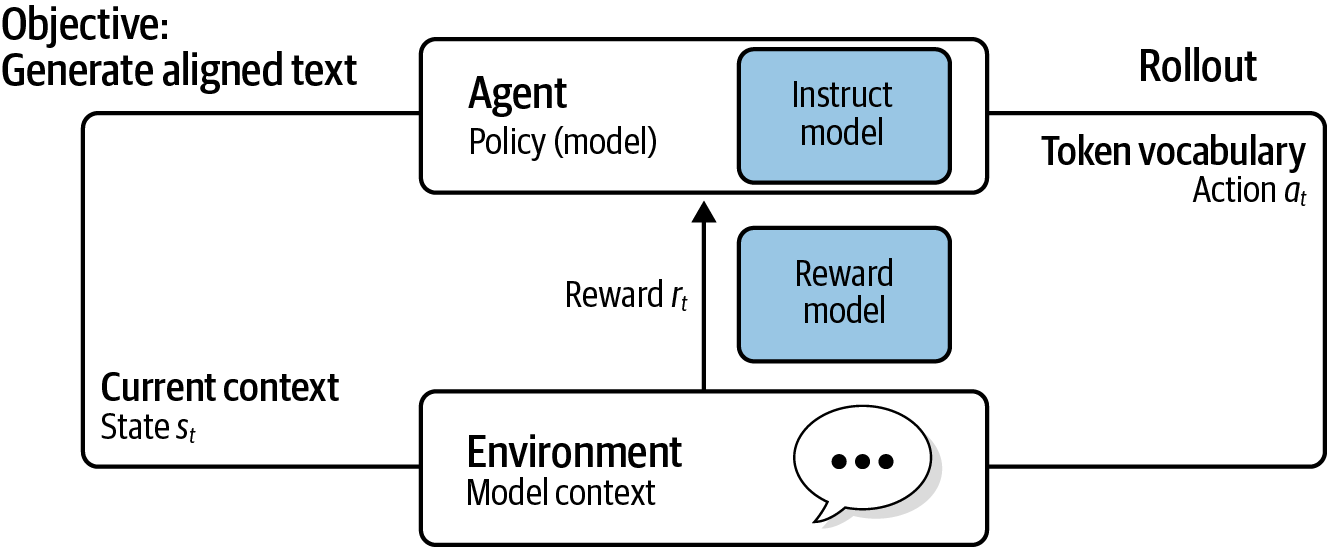

Here in case of generative model, the model is the agent. Policy consist of the model weights. The RL algorithm will update the model weights to choose a better action or generate a better next token, given the environment, state and objective. The objective is for the model to generate completions that are better aligned with human preferences such as  helpfulness, honesty and harmlessness (HHH). Action is to choose next token from vocabulary based on the probability distribution. Environment is the model's context window. State is the current token in the context window.<br>
As the model experices more rollouts and rewards, it will learn to generate tokens that produce a higher reward.<br>

*Playout is used in the classical RL while rollout is commonly used in generative context.*


## Reward model
Reward model is typically a binary classifier that predicts one of the two classes - positive or negative.  Many language models like bert already exists to classify snetiment or detect toxic language. So its better to make use of this rather than training from scratch
For example, exisisting toxicity detector model from meta is based on RoBERTa named as "roberta-hate-speech-dynabench-r4-target". Reward model predicts probability distribution across two classes - "not hate" or "hate" for a given input text.

## RLHF using PPO (Proximal Policy Optimization)

There is a popular RL algorithm called PPO used to perform the actual weight update based on the reward value assigned to a given prompt and completion. With each iteration, PPO makes small and bounded updates to the LLM weights - hence the term proximal Policy optimization. This helps fine tuning process more stable and resulting model is able to generalize well on new updates.
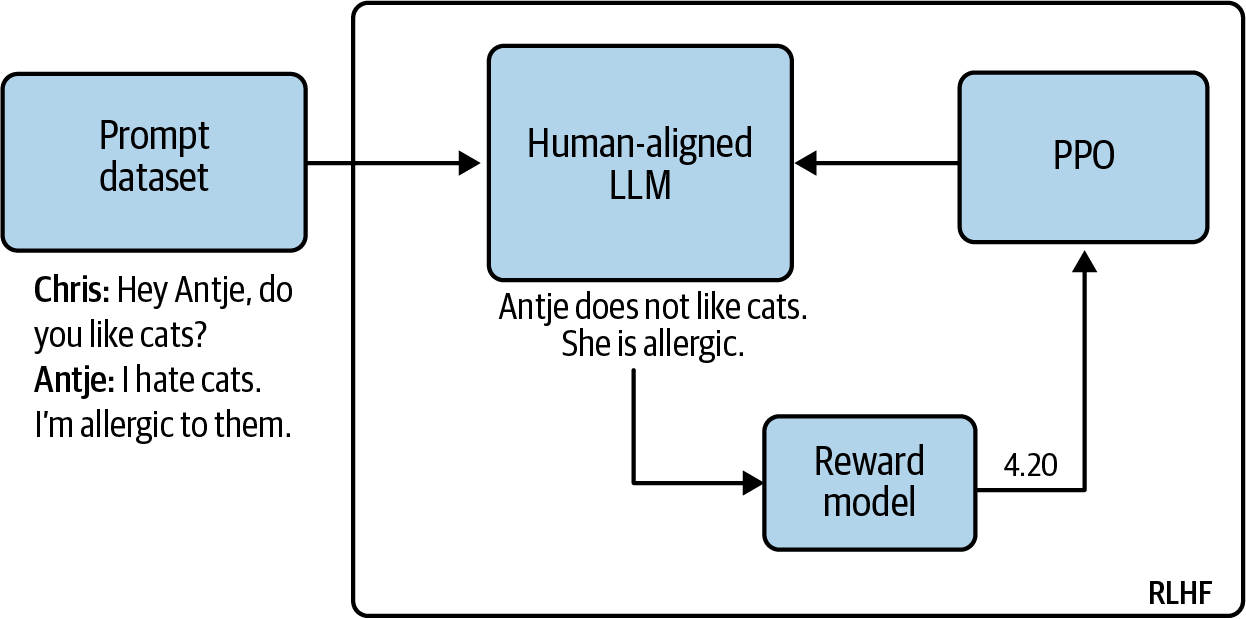

### Fine-tuning process with PPO
- First prompt is passed to generative model, which produces completion.
- Then prompt completion pair is then passed to the reward model, which provides a set of logits and probability distribution across the "not hate" and "hate" classes.
- Then these probabilies are used to optimize or update the weights of the model during backpropagation.
- Each iteration updates the model weights until model is considered aligned with human values on the basis of toxicity score or untill max_ppo_steps are reached.
- After certain number of initial iteration, model start to receive higher rewards.


## Reward Hacking
As with any reward based system, there is tendency of the model to hack the reward i.e. model can learn to cheat and maximize the reward, even if the model produce nonsensical, gramatically incorrect sequences of token and do not respect the learnings of the original model.

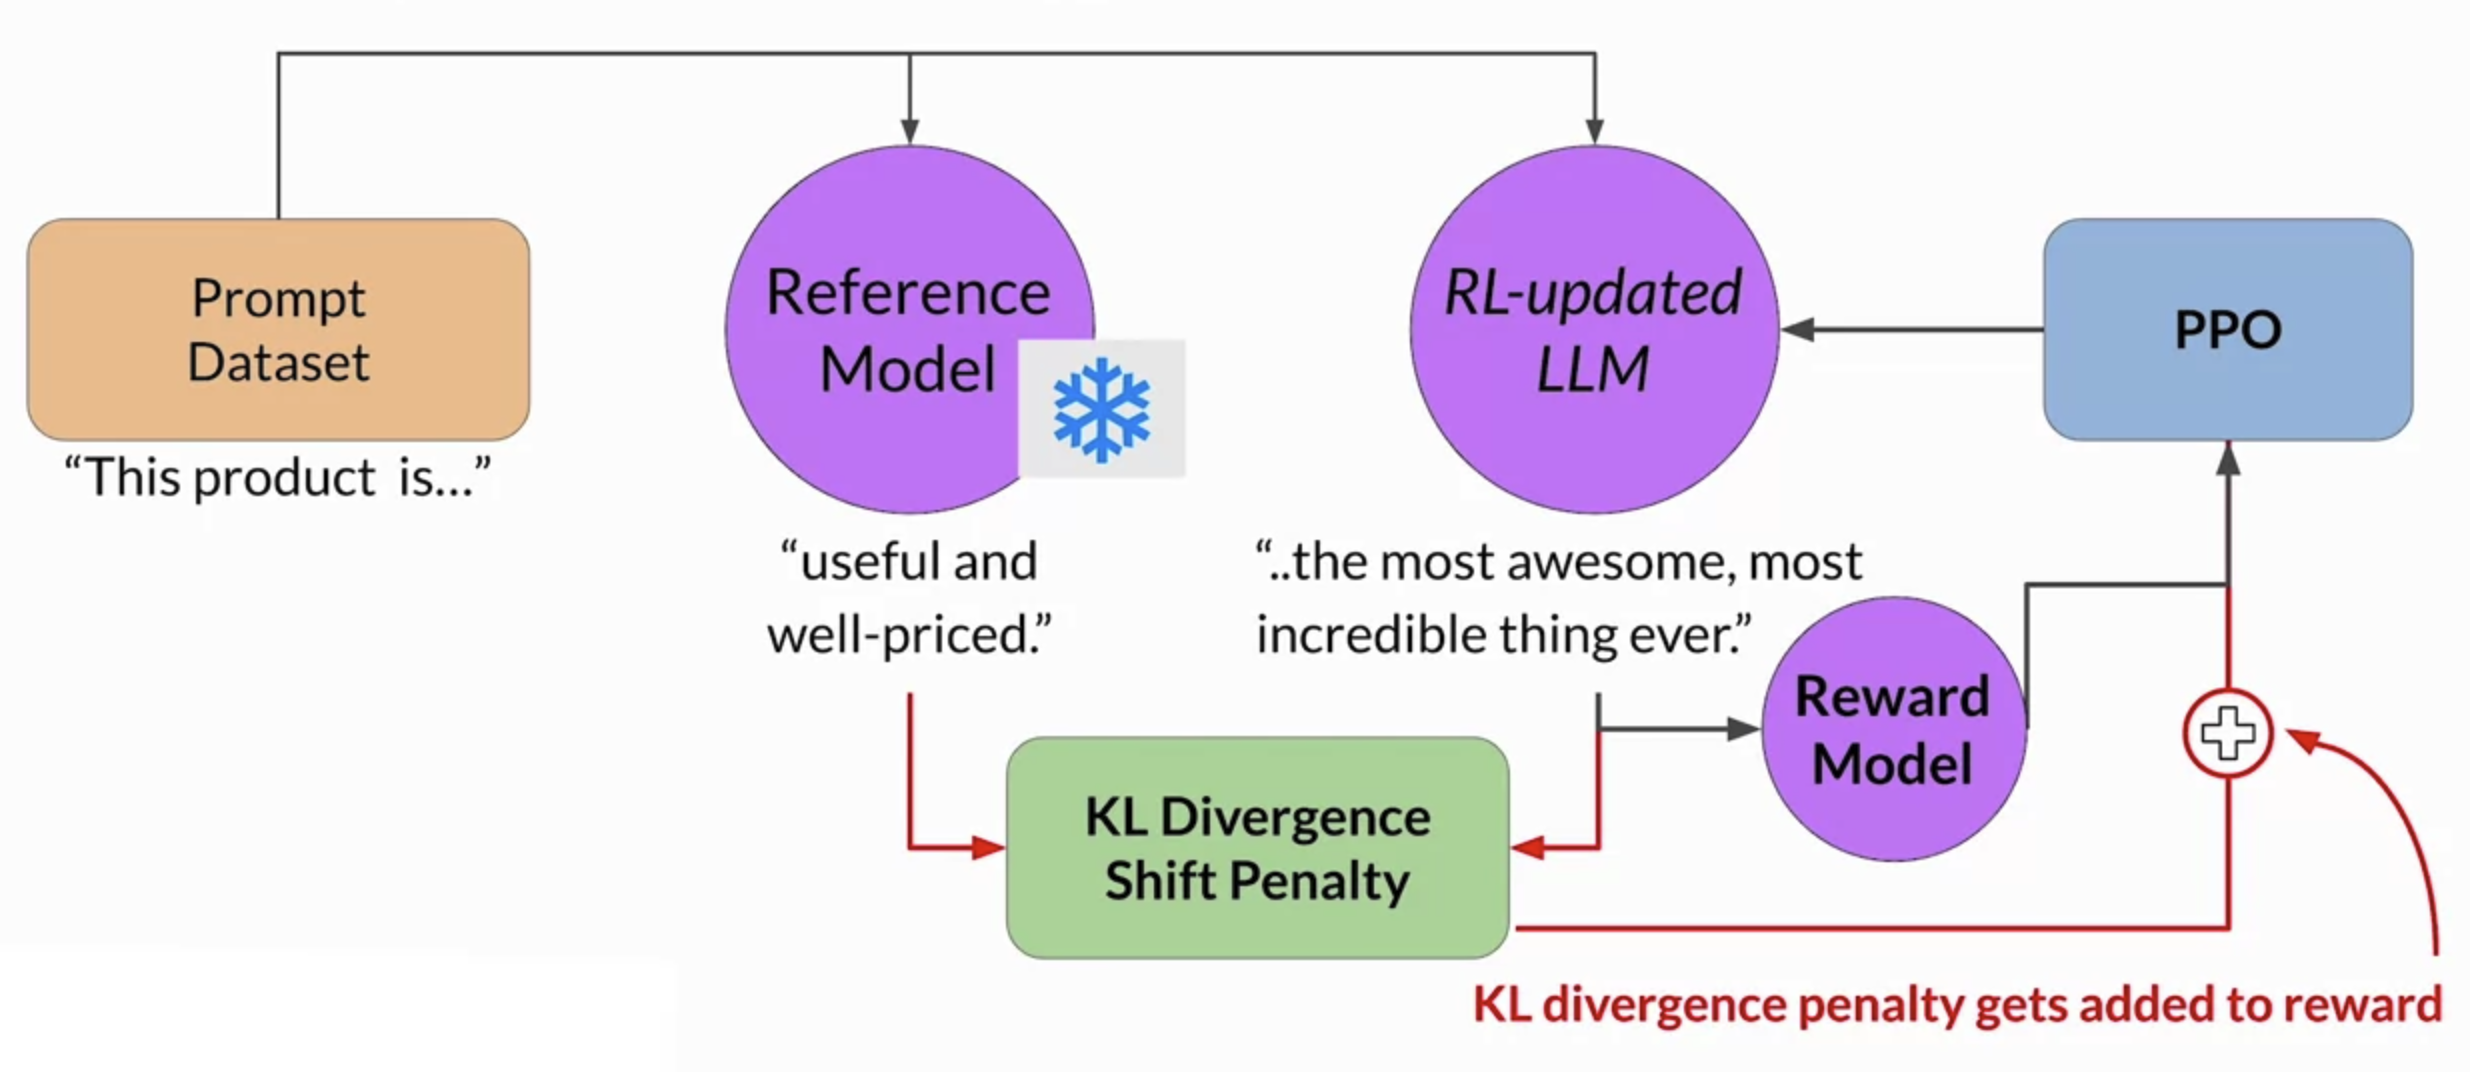

To avoid reward hacking, firt make a copy of the original instruct model. Freeze the weights of this copy and use it as a immutable "reference model". During RLHF, feed prompt to both models, frozen reference model and model to be fine-tuned, and compare the results by comparing statistical distance between two token probability distributions, calculated using KL divergence.<br>
To Summarize, if the fine-tuned model starts hacking the reward and generating sequences of tokens that diverge too far from sequence that the reference model would generate, the fine-tuned model is penalized by RL algorithm through a lower reward.

## Direct Preference Optimization

Disadvantage of PPO is that it is a complex method that needs to train at least 2 models, the reward model and the LLM, which can be more costly than perhaps necessary.

Direct Preference Optimization (DPO) is an alternative to PPO and does away with the RL based procedure. Instead of using the Reward model to judge the quality of a completion, we let LLM itself do that. Here we use a copy of the LLM as the reference model to judge the shift between the reference and trainable model in the quality of the accepted generations and rejected generations.

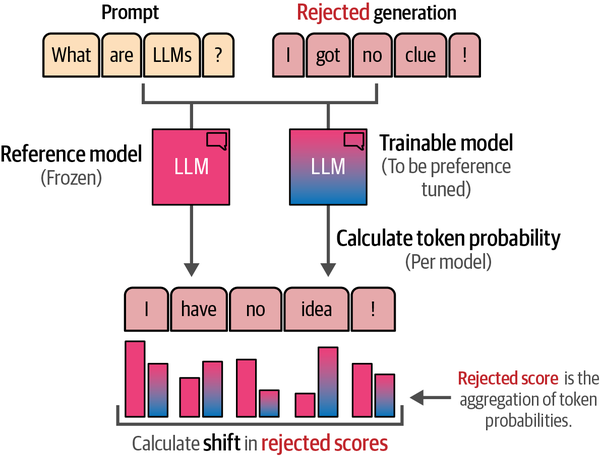

By calculating this shift during training, we can optimize the likelihood of accepted generations over rejected generations by tracking the difference in the reference model and the trainable model. To calculate this shift and its related scores, the log probabilities of the rejected generations and accepted generations are extracted from both models. This process is performed at a token level where probabilities are combined to calculate the shift between the reference and trainable models.

### Advantages over PPO
- More stable and accurate during training
- Here we don't need of Reward model, saving time and resources over training it
